# Notebook 1 — Exploración y Auditoría de Datos
**Proyecto:** Reorganización topológica de redes cerebrales y envejecimiento acelerado (ReDLaT / IIPSI)

**Fuente de datos:** `data-iipsi/` — dataset ya procesado con matrices FC (.mat) y volumetría T1w (CSV).
No requiere fMRIPrep ni imágenes NIfTI crudas.

**Pasos:**
1. Carga de metadatos clínicos y demográficos (Excel)
2. Auditoría de disponibilidad (FC y T1w)
3. Análisis descriptivo: demografía, sitio
4. Efecto de sitio pre-harmonización
5. Exportar tabla maestra y cohorte elegible para notebooks siguientes

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pingouin as pg
import statsmodels.formula.api as smf
from scipy import stats
from pathlib import Path
import re, os

sns.set_theme(style='whitegrid', palette='colorblind')
pd.set_option('display.max_columns', None)
os.makedirs('figs', exist_ok=True)
os.makedirs('outputs', exist_ok=True)

# ── Rutas ─────────────────────────────────────────────────────────────────────
DATA_ROOT = Path('data-iipsi/data')
EXCEL_PATH = DATA_ROOT / 'matrices-redlat' / 'datos-redlat.xlsx'
FC_DIR     = DATA_ROOT / 'matrices-redlat' / 'matrices-redlat'
T1W_CSV    = DATA_ROOT / 'Redlat_VGM_AAL_.csv'

# Diagnósticos a conservar
MAIN_DIAG = ['CN', 'AD', 'FTD']

print('Rutas configuradas.')
for p in [EXCEL_PATH, FC_DIR, T1W_CSV]:
    print(f'  {p.name}: {"OK" if p.exists() else "FALTA"}')

Rutas configuradas.
  datos-redlat.xlsx: OK
  matrices-redlat: OK
  Redlat_VGM_AAL_.csv: OK


## 1. Carga y normalización de metadatos

In [47]:
raw = pd.read_excel(EXCEL_PATH, sheet_name=0)
print(f'Excel cargado: {raw.shape[0]} filas, {raw.shape[1]} columnas')

# Selección y renombrado de columnas relevantes
df = raw[['record_id', 'demo_age', 'demo_sex', 'clinical_diagnosis', 'site', 'cog_ed', 'mmse_total']].copy()
df = df.rename(columns={
    'record_id':          'MRI_ID',
    'demo_age':           'Age',
    'demo_sex':           'sex',
    'clinical_diagnosis': 'diagnosis',
    'cog_ed':             'years_education',
})

df['MRI_ID']    = df['MRI_ID'].astype(str).str.strip().str.upper()
df['sex_label'] = df['sex'].map({1: 'Masculino', 2: 'Femenino'})
df['diagnosis'] = df['diagnosis'].astype(str).str.strip()

print('\nDiagnósticos:')
print(df['diagnosis'].value_counts())
print('\nSitios:')
print(df['site'].value_counts())

Excel cargado: 1365 filas, 52 columnas

Diagnósticos:
diagnosis
CN       566
AD       473
FTD      312
Other      9
AFM        3
nan        2
Name: count, dtype: int64

Sitios:
site
Miller        403
Matallana     135
Bruno         128
Takada         95
Slachevsky     95
Lopera         90
Behrens        63
Resende        19
Avila           9
Name: count, dtype: int64


## 2. Auditoría de disponibilidad de datos

In [48]:
def extract_mat_id(filename: str) -> str:
    """sub-AF025_timeseries.mat → AF025"""
    m = re.search(r'sub-([A-Za-z0-9]+)_timeseries', filename, re.IGNORECASE)
    return m.group(1).upper() if m else ''

def extract_t1w_id(raw_id: str) -> str:
    """cat_sub-AF025_T1w.xml → AF025"""
    s = str(raw_id).upper()
    s = re.sub(r'CAT_SUB-|SUB-', '', s)
    s = re.sub(r'_T1W.*|_SES.*', '', s)
    m = re.match(r'([A-Z]{2,5}\d{2,6})', s)
    return m.group(1) if m else s

# IDs con FC disponible
fc_ids = {extract_mat_id(f.name) for f in FC_DIR.glob('*.mat')}
fc_ids.discard('')
print(f'Sujetos con FC (.mat): {len(fc_ids)}')

# IDs con T1w disponible
t1w_raw = pd.read_csv(T1W_CSV, header=None)
t1w_ids = {extract_t1w_id(v) for v in t1w_raw[0]}
t1w_ids.discard('')
print(f'Sujetos con T1w (CSV): {len(t1w_ids)}')

# Flags en la tabla
df['has_FC']  = df['MRI_ID'].isin(fc_ids).astype(int)
df['has_T1w'] = df['MRI_ID'].isin(t1w_ids).astype(int)

print(f'\nIntersección Excel ∩ FC ∩ T1w: {(df.has_FC==1)&(df.has_T1w==1)}'.__class__.__name__)
print(f'Con FC:      {df.has_FC.sum()}')
print(f'Con T1w:     {df.has_T1w.sum()}')
print(f'Con FC+T1w:  {((df.has_FC==1) & (df.has_T1w==1)).sum()}')

Sujetos con FC (.mat): 1365
Sujetos con T1w (CSV): 2748
str
Con FC:      1365
Con T1w:     1280
Con FC+T1w:  1280


Disponibilidad por diagnóstico:
           has_FC  has_T1w
diagnosis                 
AD            473      427
AFM             3        3
CN            566      536
FTD           312      305
Other           9        8
nan             2        1


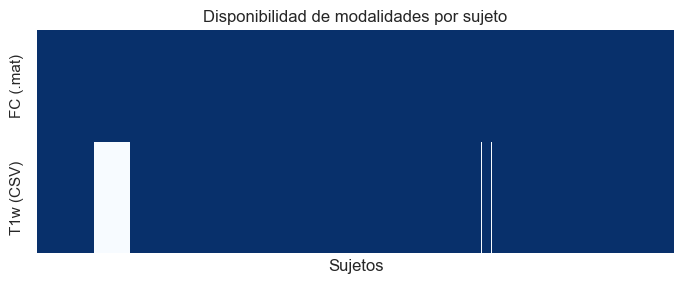

In [49]:
# N por diagnóstico y disponibilidad
print('Disponibilidad por diagnóstico:')
print(df.groupby('diagnosis')[['has_FC','has_T1w']].sum().astype(int))

# Heatmap de disponibilidad
fig, ax = plt.subplots(figsize=(7, 3))
avail = df.set_index('MRI_ID')[['has_FC','has_T1w']]
sns.heatmap(avail.T, cmap='Blues', cbar=False,
            yticklabels=['FC (.mat)', 'T1w (CSV)'], xticklabels=False, ax=ax)
ax.set_title('Disponibilidad de modalidades por sujeto')
ax.set_xlabel('Sujetos')
plt.tight_layout()
plt.savefig('figs/01_availability_heatmap.png', dpi=150)
plt.show()

In [50]:
# Cohorte elegible para análisis principal:
# diagnóstico en [CN, AD, FTD] + edad conocida + FC disponible
eligible = df[
    df['diagnosis'].isin(MAIN_DIAG) &
    df['Age'].notna() &
    (df['has_FC'] == 1)
].copy().reset_index(drop=True)

print(f'Cohorte elegible: {len(eligible)} sujetos')
print(eligible['diagnosis'].value_counts())
print(f'\nCon T1w también: {eligible.has_T1w.sum()} ({eligible.has_T1w.mean()*100:.1f}%)')

Cohorte elegible: 1327 sujetos
diagnosis
CN     555
AD     468
FTD    304
Name: count, dtype: int64

Con T1w también: 1245 (93.8%)


## 3. Análisis descriptivo

In [51]:
# Estadísticos por diagnóstico
desc_vars = ['Age', 'years_education', 'mmse_total']
desc = eligible.groupby('diagnosis')[desc_vars].agg(['mean','std','count']).reindex(MAIN_DIAG)
print(desc.round(2))

             Age              years_education             mmse_total        \
            mean    std count            mean   std count       mean   std   
diagnosis                                                                    
CN         63.27  11.37   555           16.08  3.47   402      28.97  1.29   
AD         70.02   8.53   468           12.64  5.02   394      20.02  5.81   
FTD        65.29   8.29   304           14.42  4.53   218      22.42  5.62   

                 
          count  
diagnosis        
CN          406  
AD          389  
FTD         210  


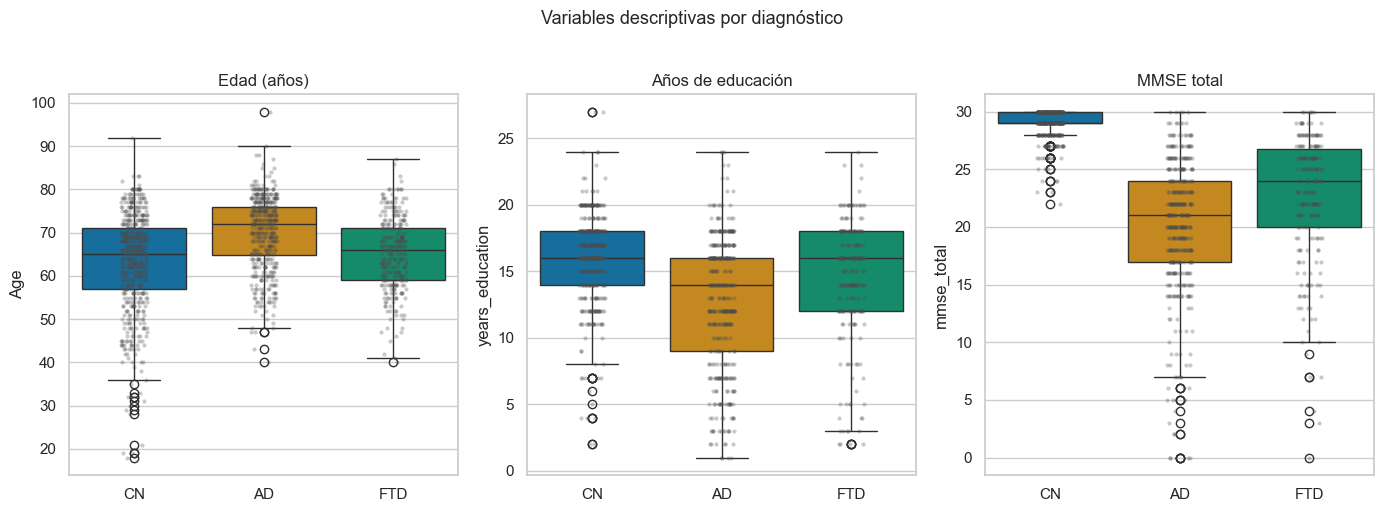

In [52]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
var_labels = {'Age': 'Edad (años)', 'years_education': 'Años de educación', 'mmse_total': 'MMSE total'}

for ax, var in zip(axes, desc_vars):
    sub = eligible.dropna(subset=[var])
    sns.boxplot(data=sub, x='diagnosis', y=var, hue='diagnosis',
                palette='colorblind', legend=False, order=MAIN_DIAG, ax=ax)
    sns.stripplot(data=sub, x='diagnosis', y=var,
                  color='0.3', alpha=0.3, size=3, order=MAIN_DIAG, ax=ax)
    ax.set_title(var_labels[var])
    ax.set_xlabel('')

plt.suptitle('Variables descriptivas por diagnóstico', y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig('figs/01_desc_vars_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_3900\2251037650.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=eligible, x='diagnosis', y='Age', order=MAIN_DIAG,


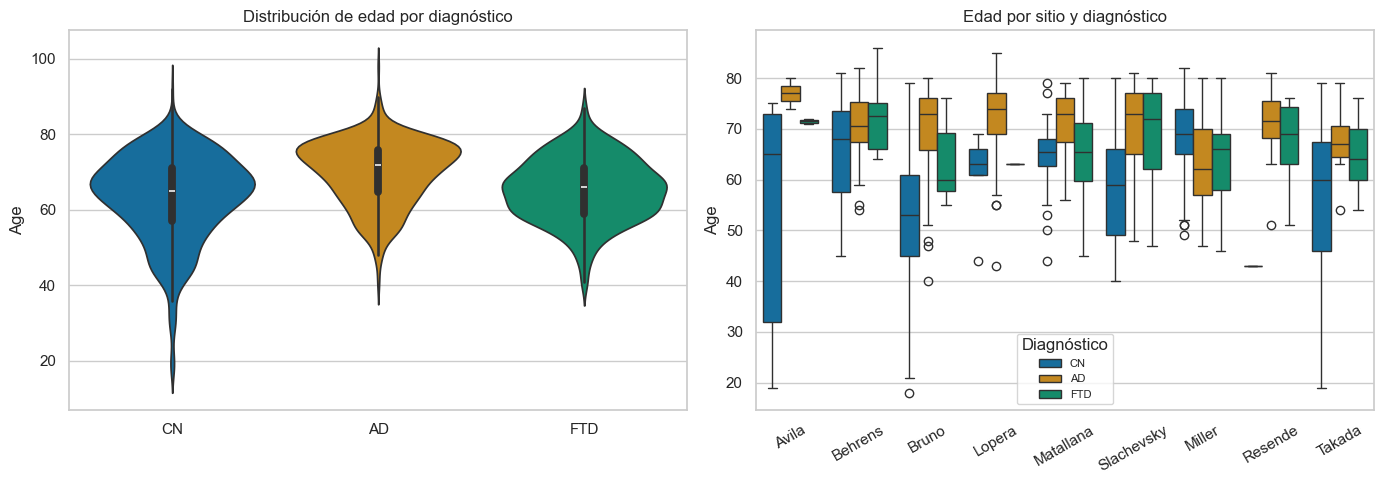

In [53]:
# Distribución de edad
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.violinplot(data=eligible, x='diagnosis', y='Age', order=MAIN_DIAG,
               palette='colorblind', inner='box', ax=axes[0])
axes[0].set_title('Distribución de edad por diagnóstico')
axes[0].set_xlabel('')

sns.boxplot(data=eligible, x='site', y='Age', hue='diagnosis',
            hue_order=MAIN_DIAG, palette='colorblind', ax=axes[1])
axes[1].set_title('Edad por sitio y diagnóstico')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(title='Diagnóstico', fontsize=8)

plt.tight_layout()
plt.savefig('figs/01_age_distributions.png', dpi=150)
plt.show()

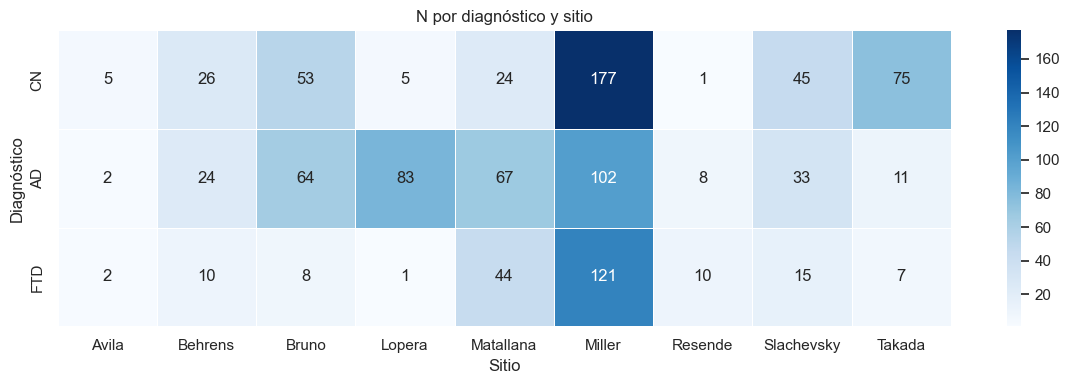

site       Avila  Behrens  Bruno  Lopera  Matallana  Miller  Resende  \
diagnosis                                                              
CN             5       26     53       5         24     177        1   
AD             2       24     64      83         67     102        8   
FTD            2       10      8       1         44     121       10   

site       Slachevsky  Takada  
diagnosis                      
CN                 45      75  
AD                 33      11  
FTD                15       7  


In [54]:
# N por diagnóstico y sitio
ct = pd.crosstab(eligible['diagnosis'], eligible['site']).reindex(MAIN_DIAG)

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(ct, annot=True, fmt='d', cmap='Blues', linewidths=0.5, ax=ax)
ax.set_title('N por diagnóstico y sitio')
ax.set_xlabel('Sitio')
ax.set_ylabel('Diagnóstico')
plt.tight_layout()
plt.savefig('figs/01_diagnosis_site_crosstab.png', dpi=150)
plt.show()
print(ct)

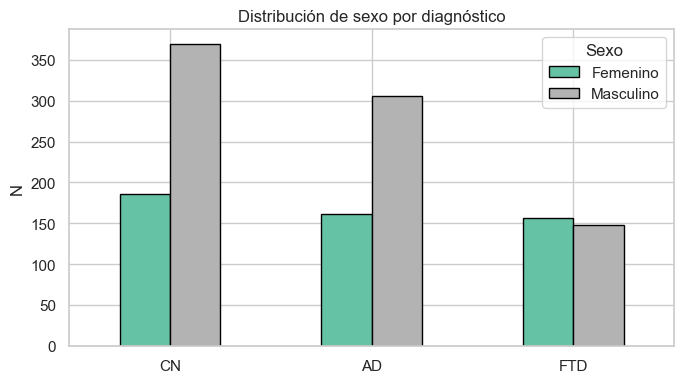

sex_label  Femenino  Masculino
diagnosis                     
CN              186        369
AD              162        306
FTD             156        148


In [55]:
# Distribución de sexo por diagnóstico
sex_ct = pd.crosstab(eligible['diagnosis'], eligible['sex_label']).reindex(MAIN_DIAG)
sex_ct.plot(kind='bar', colormap='Set2', figsize=(7, 4), edgecolor='black')
plt.title('Distribución de sexo por diagnóstico')
plt.xlabel('')
plt.ylabel('N')
plt.xticks(rotation=0)
plt.legend(title='Sexo')
plt.tight_layout()
plt.savefig('figs/01_sex_by_diagnosis.png', dpi=150)
plt.show()
print(sex_ct)

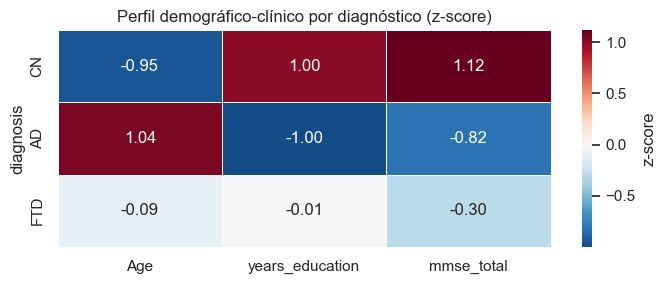

In [56]:
# Perfil z-score multivariado
profile = eligible.dropna(subset=desc_vars).groupby('diagnosis')[desc_vars].mean().reindex(MAIN_DIAG)
profile_z = (profile - profile.mean()) / profile.std()

fig, ax = plt.subplots(figsize=(7, 3))
sns.heatmap(profile_z, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            linewidths=0.5, ax=ax, cbar_kws={'label': 'z-score'})
ax.set_title('Perfil demográfico-clínico por diagnóstico (z-score)')
plt.tight_layout()
plt.savefig('figs/01_profile_heatmap.png', dpi=150)
plt.show()

## 4. Efecto de sitio (pre-harmonización)

In [57]:
# ANOVA: ¿difieren los sitios en edad y educación?
for var in ['Age', 'years_education']:
    aov = pg.anova(data=eligible.dropna(subset=[var]), dv=var, between='site')
    print(f'ANOVA {var} ~ site:')
    print(aov[['Source', 'F', 'p_unc', 'np2']].to_string(index=False))
    print()

ANOVA Age ~ site:
Source         F        p_unc      np2
  site 13.900103 2.740524e-19 0.098828

ANOVA years_education ~ site:
Source         F        p_unc      np2
  site 34.464786 2.703577e-48 0.215284



In [58]:
# Regresión: ¿el sitio predice MMSE después de controlar edad y diagnóstico?
df_model = eligible.dropna(subset=['mmse_total', 'Age', 'years_education'])
if len(df_model) > 50:
    model = smf.ols(
        'mmse_total ~ Age + years_education + C(diagnosis) + C(site)',
        data=df_model
    ).fit()
    print(model.summary().tables[1])
else:
    print('Datos insuficientes para el modelo.')

                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                14.1418      2.355      6.006      0.000       9.521      18.763
C(diagnosis)[T.CN]        9.1802      0.362     25.332      0.000       8.469       9.891
C(diagnosis)[T.FTD]       3.0552      0.405      7.550      0.000       2.261       3.849
C(site)[T.Behrens]       -2.0748      2.046     -1.014      0.311      -6.089       1.939
C(site)[T.Bruno]          0.1060      2.010      0.053      0.958      -3.839       4.051
C(site)[T.Lopera]        -0.1934      2.024     -0.096      0.924      -4.166       3.779
C(site)[T.Matallana]     -1.4520      1.997     -0.727      0.467      -5.371       2.467
C(site)[T.Miller]        -2.7377      1.976     -1.385      0.166      -6.616       1.140
C(site)[T.Resende]        0.3859      2.208      0.175      0.861      -3.946       4.718
C(site)[T.

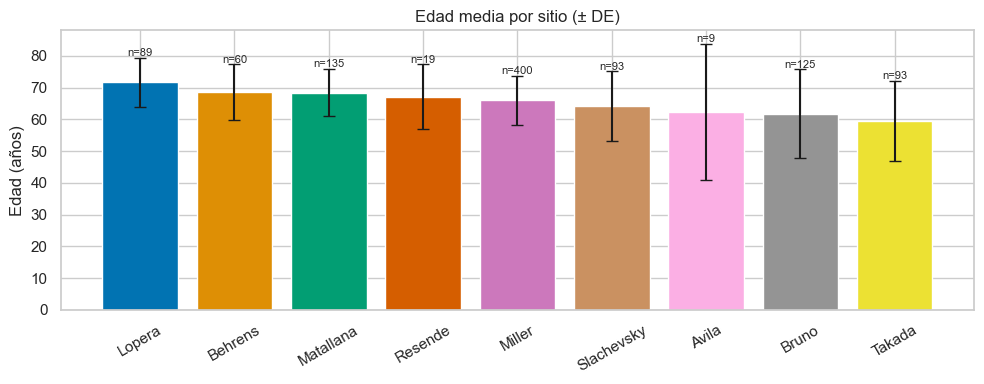

In [59]:
# Edad media por sitio
fig, ax = plt.subplots(figsize=(10, 4))
site_age = eligible.groupby('site')['Age'].agg(['mean', 'std', 'count'])
site_age = site_age.sort_values('mean', ascending=False)
ax.bar(site_age.index, site_age['mean'], yerr=site_age['std'],
       capsize=4, color=sns.color_palette('colorblind', len(site_age)))
for i, (site, row) in enumerate(site_age.iterrows()):
    ax.text(i, row['mean'] + row['std'] + 0.5, f'n={int(row["count"])}',
            ha='center', fontsize=8)
ax.set_title('Edad media por sitio (± DE)')
ax.set_ylabel('Edad (años)')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('figs/01_age_by_site.png', dpi=150)
plt.show()

## 5. Exportar tabla maestra y cohorte elegible

In [60]:
# Tabla maestra completa (todos los diagnósticos)
df.to_csv('outputs/master_table.csv', index=False)

# Cohorte elegible para análisis FC + grafos
eligible.to_csv('outputs/eligible_fc_subjects.csv', index=False)

print(f'Tabla maestra exportada: {len(df)} sujetos')
print(f'Elegibles FC exportados: {len(eligible)} sujetos')
print(f'  CN:  {(eligible.diagnosis=="CN").sum()}')
print(f'  AD:  {(eligible.diagnosis=="AD").sum()}')
print(f'  FTD: {(eligible.diagnosis=="FTD").sum()}')
print(f'  Con T1w también: {eligible.has_T1w.sum()}')

Tabla maestra exportada: 1365 sujetos
Elegibles FC exportados: 1327 sujetos
  CN:  555
  AD:  468
  FTD: 304
  Con T1w también: 1245


In [61]:
# Resumen final
print('=== RESUMEN AUDITORÍA ===')
print(f'Total sujetos en Excel:    {len(df)}')
print(f'Con FC (.mat):             {df.has_FC.sum()}')
print(f'Con T1w (CSV):             {df.has_T1w.sum()}')
print(f'Cohorte elegible (CN/AD/FTD + FC + edad): {len(eligible)}')
print(f'Sitios: {eligible["site"].nunique()} → {sorted(eligible["site"].unique())}')
print(f'Rango de edad: {eligible["Age"].min():.0f}–{eligible["Age"].max():.0f} años')
print(f'Edad media (DT): {eligible["Age"].mean():.1f} ({eligible["Age"].std():.1f})')

=== RESUMEN AUDITORÍA ===
Total sujetos en Excel:    1365
Con FC (.mat):             1365
Con T1w (CSV):             1280
Cohorte elegible (CN/AD/FTD + FC + edad): 1327


TypeError: '<' not supported between instances of 'float' and 'str'